In [2]:
import numpy as np
import scipy.fft as fft
import matplotlib.pyplot as plt

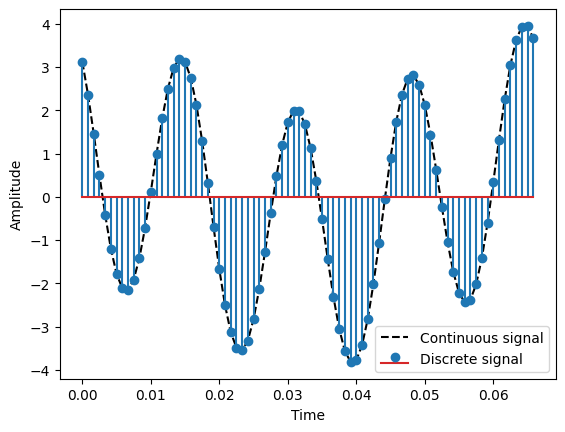

In [3]:
# Generate a sample "continuous" signal
# Two constant frequencies
f1 = 15 # Hz
f2 = 60 # Hz

# and phase shifts
p1 = 0
p2 = np.pi / 4

# and amplitudes
a1 = 1
a2 = 3

# Time interval
T = 1 / (f2 * 20)

# period is the greatest common denominator of the two frequencies
P = 1 / np.gcd(int(f1), int(f2))

# Number of samples
N = int(P / T)

t = np.arange(N) * T
x = a1 * np.cos(f1 * 2*np.pi*t + p1) + a2 *np.cos(f2 * 2*np.pi*t + p2)

plt.plot(t, x, "k--", label="Continuous signal")
plt.stem(t, x, label="Discrete signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.legend()

(0.0, 200.0)

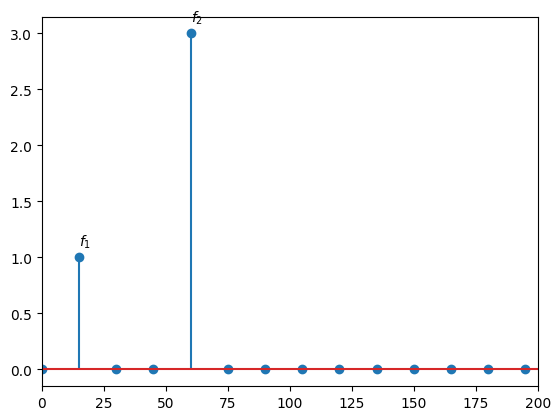

In [4]:
X = fft.fft(x) * 2 / N
k = fft.fftfreq(N, d=T)

plt.stem(k, abs(X))
plt.text(f1, a1 + 0.1, "$f_1$")
plt.text(f2, a2 + 0.1, "$f_2$")
plt.xlim([0,200])

Text(0, 0.5, 'Phase')

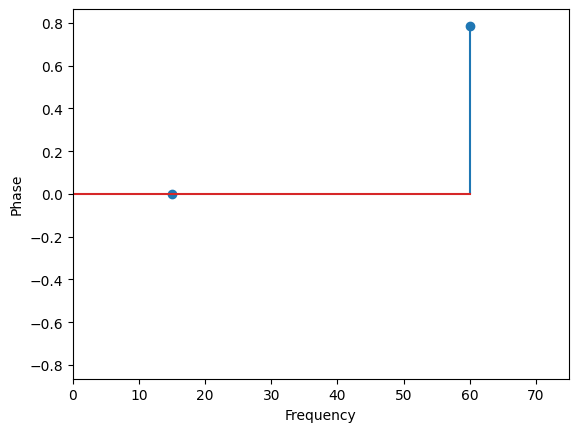

In [5]:
# Phase
mask = abs(X) > 0.1
plt.stem(k[mask], np.angle(X[mask]))
plt.xlim([0, f2 + f1])
plt.xlabel("Frequency")
plt.ylabel("Phase")

In [6]:
# helper function for time and frequency plotting
def plot_time_and_freq(t, x, tlim=None, flim=None):
    _, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(t, x)
    axes[0].set_xlabel("Time (seconds)")
    axes[0].set_ylabel("Amplitude (V)")
    if tlim:
        axes[0].set_xlim(tlim)

    N = len(x)
    dt = t[1] - t[0]
    X = fft.fftshift(fft.fft(x) * dt)
    f = fft.fftshift(fft.fftfreq(N, d=dt))
    axes[1].plot(f, abs(X))
    axes[1].set_xlabel("Frequency (Hz)")
    axes[1].set_ylabel("Amplitude (V/Hz)")
    if flim:
        axes[1].set_xlim(flim)

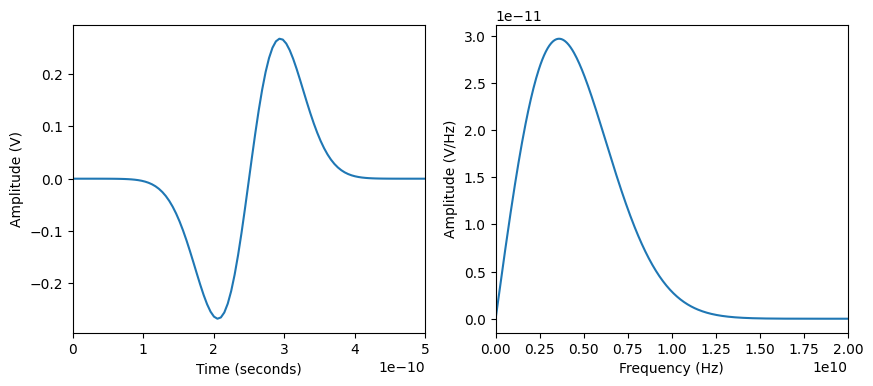

In [7]:
# tsar pulse, just for funsies
tau_p = 62.5e-12
t0 = 4 * tau_p
P0 = 10e9

t = np.linspace(0, 20e-9, 4096)
p = P0 * (t-t0) * np.exp(-(t-t0)**2/tau_p**2)

plot_time_and_freq(t, p, [0, 0.5e-9], [0, 20e9])

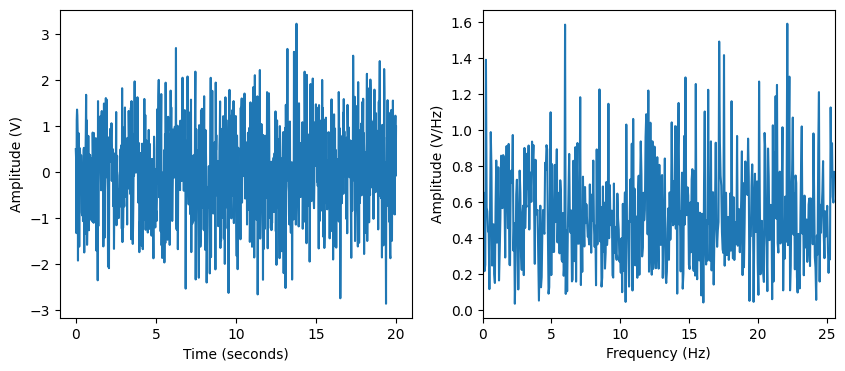

In [8]:
# white noise
rng = np.random.default_rng(seed=318)
t = np.linspace(0, 20, 1024)
noise = rng.standard_normal(t.shape)

plot_time_and_freq(t, noise, flim=[0, 0.5/(t[1] - t[0])])

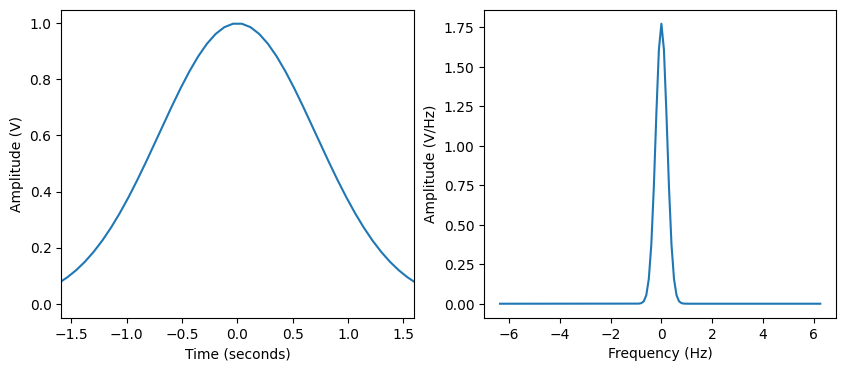

In [9]:
# Finally, what's special about a gaussian?
t = np.linspace(-5,5,128)

x = np.exp(-t**2)
plot_time_and_freq(t, x, [-5 / np.pi, 5 / np.pi])

## Audio Data
Samples downloaded from [AudioMNIST](https://github.com/soerenab/AudioMNIST/tree/master).

In [10]:
from scipy.io import wavfile
import IPython.display as ipd

In [11]:
# Load the two audio files
sr_00, zero_0 = wavfile.read("0_01_0.wav")
sr_01, zero_1 = wavfile.read("0_01_1.wav")

# what did that return?
print(sr_00, zero_0.shape)
print(sr_01, zero_1.shape)

48000 (35877,)
48000 (31356,)


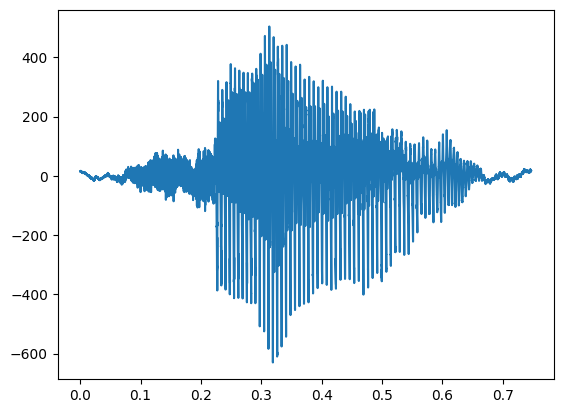

In [12]:
t = np.arange(len(zero_0)) / sr_00
plt.plot(t, zero_0)

In [13]:
# listen to it
ipd.Audio(zero_0, rate=sr_00)

In [14]:
# How about a single tone?
tone = np.cos(440 * 2*np.pi*t)
ipd.Audio(tone, rate=sr_00)

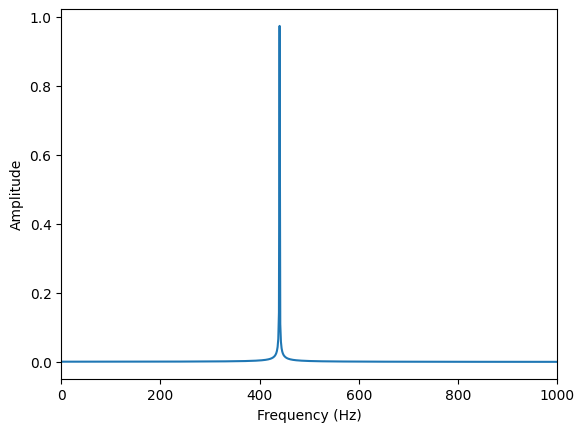

In [15]:
# what does the frequency version look like?
def plot_freq(audio, sr, max_f):
    N = len(audio)
    F = fft.fft(audio) * 2 / N
    k = fft.fftfreq(N, d=1/sr)
    plt.plot(k[:N//2], abs(F[:N//2]))
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude")
    plt.xlim([0, max_f])

plot_freq(tone, sr_00, 1000)

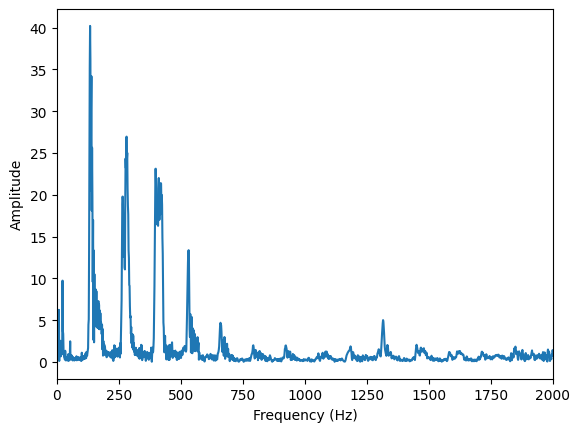

In [16]:
# What about the zero?
plot_freq(zero_0, sr_00, 2000)

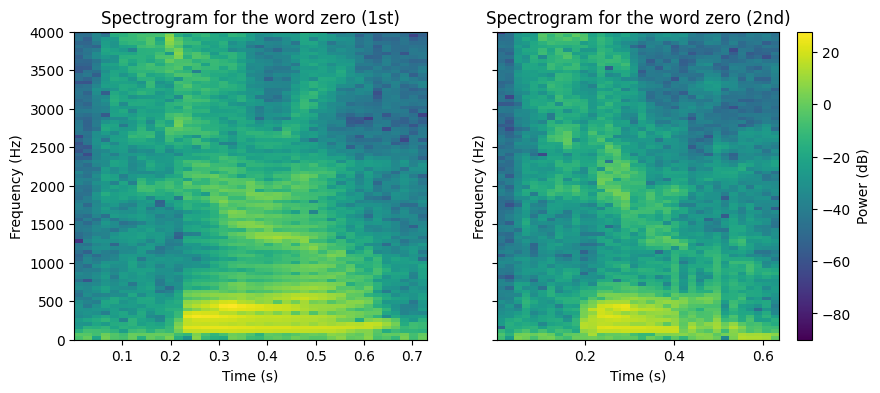

In [17]:
# a spectrogram is a windowed FFT that tries to combine time and frequency information
fig, axes = plt.subplots(1, 2, figsize=(10,4), sharey=True)
spec0 = axes[0].specgram(zero_0, NFFT=1024, Fs=sr_00)
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Frequency (Hz)")
plt.ylim([0, 4000])
axes[0].set_title("Spectrogram for the word zero (1st)")

# find the min/max of the PSD
min_p = 10 * np.log10(spec0[0].min())
max_p = 10 * np.log10(spec0[0].max())

spec1 = axes[1].specgram(zero_1, NFFT=1024, Fs=sr_00, vmin=min_p, vmax=max_p)
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Frequency (Hz)")
plt.ylim([0, 4000])
axes[1].set_title("Spectrogram for the word zero (2nd)")

# colourbar should apply to both now
fig.colorbar(spec1[-1], label="Power (dB)")

In [18]:
10 * np.log10(spec0[0].min())

np.float64(-90.05551051756164)

(0.0, 2000.0)

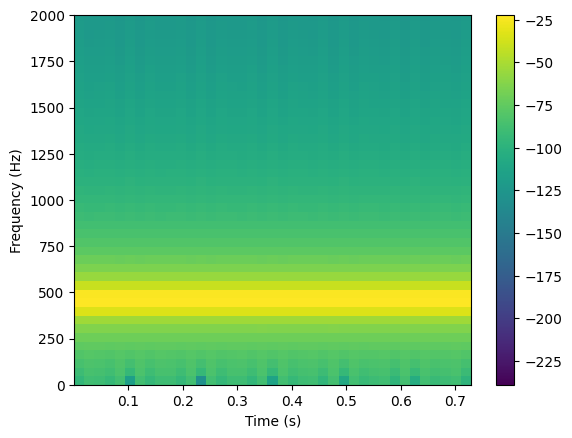

In [19]:
plt.specgram(tone, NFFT=1024, Fs=sr_00)
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.colorbar()
plt.ylim([0, 2000])

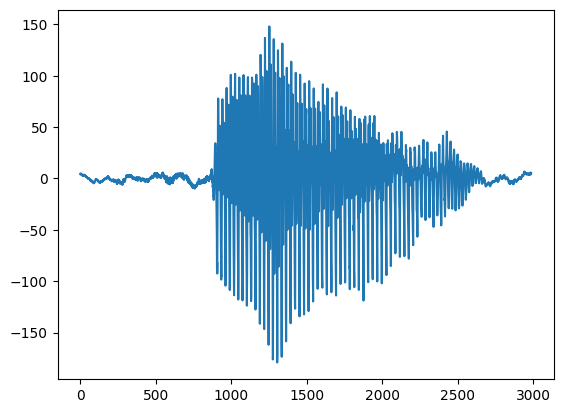

In [20]:
# What if we truncate and bring back to time?
zero_F = fft.fft(zero_0) * 2 / N
k = fft.fftfreq(len(zero_0), d=1/sr_00)
new_br = 4000
lp_zero = np.real(fft.ifft(zero_F[abs(k) < new_br / 2]))
plt.plot(lp_zero)

# What does it sound like?
ipd.Audio(lp_zero, rate=new_br)

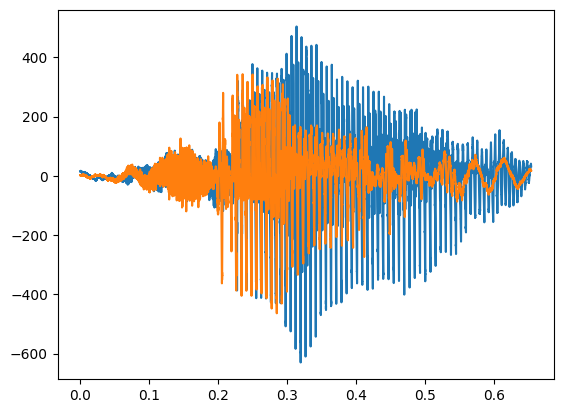

In [21]:
# just for fun, mash the two channels together
N = min(len(zero_0), len(zero_1))
two_chan = np.vstack([zero_0[:N], zero_1[:N]])
two_chan.shape

plt.plot(t[:N], two_chan.T)

ipd.Audio(two_chan, rate=sr_00)

## Librosa
`scipy.io.wavfile` gives us low-level access to the raw numbers, but `librosa` provides handy tools specifically for working with audio.

In [22]:
%pip install -q librosa

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
import librosa
lr_zero_0, lr_sr_0 = librosa.load("0_01_0.wav")

In [24]:
# what's different?
print(f"librosa sample rate: {lr_sr_0}, original sample rate: {sr_00}")
print(f"librosa data type: {lr_zero_0[0].dtype}, original data type: {zero_0[0].dtype}")

# what if I want the original sample rate?
lr_zero_0, lr_sr_0 = librosa.load("0_01_0.wav", sr=None)

# What is the scaling factor?
print(zero_0[0] / lr_zero_0[0])
print(2**(16 - 1)) # 16 bits, looks like it's rescaled to -1 to 1

librosa sample rate: 22050, original sample rate: 48000
librosa data type: float32, original data type: int16
32768.0
32768


In [25]:
# This sample is fine downsampled, so we'll go back to librosa defaults
lr_zero_0, sr = librosa.load("0_01_0.wav")
lr_zero_1, _ = librosa.load("0_01_1.wav")

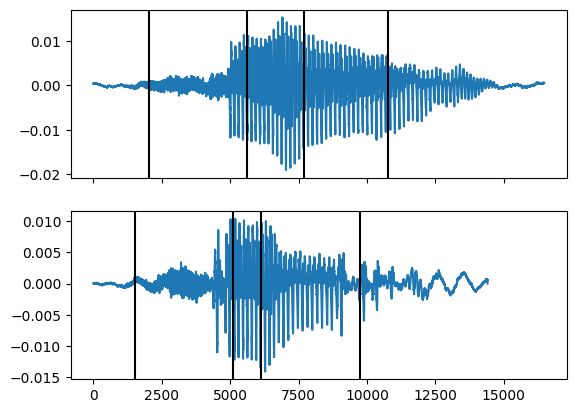

In [26]:
# What do the two "zero" signals look like?
def plot_onset(y, ax):
    os = librosa.onset.onset_detect(y=y, sr=sr, units="samples")
    ax.plot(y)
    for o in os:
        ax.axvline(x=o, color="k")
    
    return os

fig, axes = plt.subplots(2, 1, sharex=True)
os0 = plot_onset(lr_zero_0, axes[0])
os1 = plot_onset(lr_zero_1, axes[1])

[ 512  512 1536 1024]


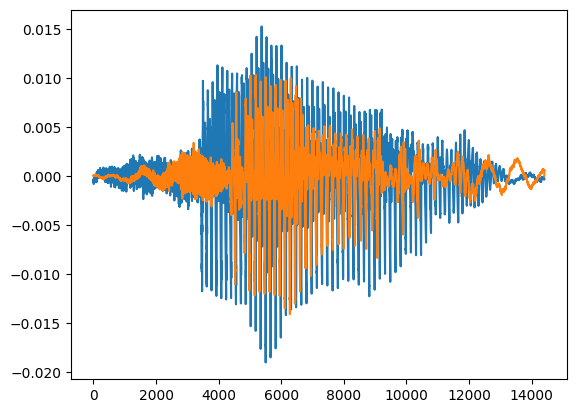

In [27]:
# what's the shift between them?
print(os0 - os1)
shift = os0[2] - os1[2]

# align and crop to the same size
stereo = np.vstack([lr_zero_0[shift:shift+len(lr_zero_1)], lr_zero_1])

plt.plot(stereo.T)
ipd.Audio(stereo, rate=sr)